<a href="https://colab.research.google.com/github/spyrosgaroufalis/TorchTest/blob/nn.classification/NN_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# data
import sklearn
import sklearn.datasets
from sklearn.datasets import make_circles

# make 1000 samples
n_samples = 1000

# create circles
X, y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)
len(X), len(y)

(1000, 1000)

In [2]:
print(f"first 5 samples of X: \n{X[:5]}")
print(f"first 5 samples of y: {y[:5]}")

first 5 samples of X: 
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first 5 samples of y: [1 1 1 1 0]


In [3]:
# make dataframe of circle data
import pandas as pd
circles = pd.DataFrame({
    "X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


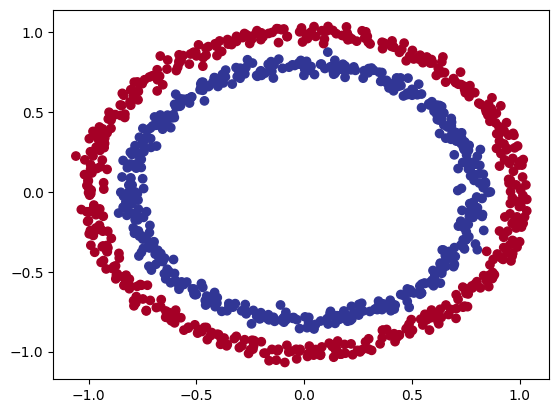

In [4]:
# visualise
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);
#

**How to differentiate one circle from another?**

In [5]:
X.shape, y.shape # so we have arrays

((1000, 2), (1000,))

In [6]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [7]:
# view the first
X_sample = X[0]
y_sample = y[0]

print(f"values for one sample of X: {X_sample} and the same for y : {y_sample}")
print(f"sahpes for one sample fo X: {X_sample.shape} and y: {y_sample.shape}")


values for one sample of X: [0.75424625 0.23148074] and the same for y : 1
sahpes for one sample fo X: (2,) and y: ()


In [8]:
# turn into tensors and train-test splits

In [9]:
import torch
torch.__version__

'2.11.0+cu128'

In [10]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [11]:
import torch
# turn into tens
# X = X.to(torch.float32)
# X = torch.from_numpy(X).type(torch.float)
# y = torch.from_numpy(y).type(torch.float)
# y = y.to(torch.float32)

X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [12]:
type(X), type(y), X.dtype, y.dtype

(numpy.ndarray, numpy.ndarray, dtype('float64'), dtype('int64'))

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

**BUILD THE MODEL**

1. device agnostic \n
2. constract a model ( by subclassing nn.Module)
3. define loss fn and optimiser
4. create training and test loop


In [14]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [16]:
y_train[:5]

array([1, 0, 0, 0, 1])

In [17]:

class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    # 2. create 2 nn.Linear layers capable of handling our data
    self.layer_1 = nn.Linear(in_features=2, out_features=5) # take 2 features(tensor is shape(800,2) and use linear formula and upscale to 5 features
    # when we upscale to 5 we have more data to learn patterns from
    self.layer_1 = nn.Linear(in_features=5, out_features=1)# in needs to match the previous layer
    # above is same shape as y

    # we could add nn.sequential here
    # self.two_linear_layers = nn.Sequential(
    #     nn.Linear(in_features=2, out_features=5),
    #     nn.Linear(in_features=5, out_features=1)
    # )

  #3. define forward method
  def forward(self, x):
    return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> output
    # now we can return the sequential
    # return two_linear_layers(x)
  #4. instantiate an instance of our model class and send it to target device

model_0 = CircleModelV0().to(device)
model_0


CircleModelV0(
  (layer_1): Linear(in_features=5, out_features=1, bias=True)
)

In [18]:
next(model_0.parameters()).device

device(type='cuda', index=0)

**Replicate using nn.sequenstial**

**does the same**


In [19]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [20]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0307,  0.3435],
                      [ 0.2798, -0.5421],
                      [-0.2750, -0.0997],
                      [-0.6494,  0.2128],
                      [-0.1196, -0.5651]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.3776,  0.5257,  0.3371, -0.2169,  0.5244], device='cuda:0')),
             ('1.weight',
              tensor([[-0.2819, -0.3095, -0.4058,  0.3258, -0.3553]], device='cuda:0')),
             ('1.bias', tensor([0.1500], device='cuda:0'))])

**MAKE PREDS**

In [21]:
# make preds
# first if we have xtest as numpy array we need to make it pytorch tensor
X_test_tensor = torch.from_numpy(X_test).type(torch.float).to(device)
y_test_tensor = torch.from_numpy(y_test).type(torch.float).to(device)
with torch.inference_mode():
  untrained_preds = model_0(X_test_tensor)
print(f"length of predictions: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"length of test samples: {len(X_test)}, shape: {X_test.shape}")
print(f"first 10 predictions:\n {untrained_preds[:10]}")
print(f"first 10 labels: \n {y_test[:10]}")


length of predictions: 200, shape: torch.Size([200, 1])
length of test samples: 200, shape: (200, 2)
first 10 predictions:
 tensor([[-0.2016],
        [-0.1487],
        [-0.5378],
        [-0.1056],
        [-0.8511],
        [-0.8164],
        [-0.4190],
        [-0.5762],
        [-0.5241],
        [-0.1486]], device='cuda:0')
first 10 labels: 
 [1 0 1 0 1 1 0 0 1 0]


**SETUP LOSS FN AND OPTIMISER**

In [22]:
# loss_fn = nn.BCELoss() # exists lol
# bce with logits loss combines bceloss and sigmoid, smth like this:
# nn.Sequential(
#     nn.Sigmoid(),
#     nn.BCELoss()
# )

loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation function

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

**CREATE EVAL METRIC**

In [23]:
# calc accuracy, what persentage the model gets right
# google the formula
# true pos/(true positive + true negative)*100

def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
  acc = (correct / len(y_pred)) * 100
  return acc
#

**NOW TRAIN MODEL**

**LOGIT= RAW MODEL OUTPUT**

In [24]:
# we go from logits -> prediction probabiblities -> prediction labels

# view the 5 outputs
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test_tensor.to(device))[:5]
y_logits

tensor([[-0.2016],
        [-0.1487],
        [-0.5378],
        [-0.1056],
        [-0.8511]], device='cuda:0')

In [25]:
y_test_tensor[:5]

tensor([1., 0., 1., 0., 1.], device='cuda:0')

In [26]:
# use the sigmoid activation function to turn logits into pred probab

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4498],
        [0.4629],
        [0.3687],
        [0.4736],
        [0.2992]], device='cuda:0')

In [27]:
# find the predicted labels
y_preds = torch.round(y_pred_probs)
# y_preds
# in full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test_tensor.to(device))[:5]))
y_pred_labels

# check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [28]:
y_test[:5]

array([1, 0, 1, 0, 1])

In [29]:
# bulding the training and testing loop

In [36]:
# turn into tensors
X_train_tensor = torch.from_numpy(X_train).type(torch.float).to(device)
X_test_tensor = torch.from_numpy(X_test).type(torch.float).to(device)
y_train_tensor = torch.from_numpy(y_train).type(torch.float).to(device)
y_test_tensor = torch.from_numpy(y_test).type(torch.float).to(device)
#

In [38]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# epochs
epochs = 100

# put data to device
X_train_tensor, y_train_tensor = X_train_tensor.to(device), y_train_tensor.to(device)
X_test_tensor, y_test_tensor = X_test_tensor.to(device), y_test_tensor.to(device)


# build training, eval loop
for epoch in range(epochs):
  # 1. training
  model_0.train()

  # 2. forward pass
  y_logits = model_0(X_train_tensor).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits-> pred probs-> pred labels

  # 3. loss/accuracy
  # if we did nn.BCELoss we expect pred probs as input:
  # loss = loss_fn(torch.sigmoid(y_logits),
                #  y_train)
  loss = loss_fn(y_logits, y_train_tensor) # nn.bcewithlogitsloss expects raw logits as input
  acc = accuracy_fn(y_true=y_train_tensor,
                    y_pred=y_pred)

  # 4. optimizer zero grad
  optimizer.zero_grad()

  # 5. loss backward
  loss.backward()

  # 6. optimizer step ( gradient descent)
  optimizer.step()

  # testing
  model_0.eval()
  with torch.inference_mode():
    #1. forward pass
    test_logits = model_0(X_test_tensor).squeeze() # get rid of extra 1 dim
    test_pred = torch.round(torch.sigmoid(test_logits))
    #2. loss
    test_loss = loss_fn(test_logits, y_test_tensor)
    test_acc = accuracy_fn(y_true=y_test_tensor,
                           y_pred=test_pred)
  #print whats happenin
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | loss: {loss:.5f}, acc: {acc:.2f}% | test_loss: {test_loss:.5f}, test_acc: {test_acc:.2f}%")



Epoch: 0 | loss: 0.73267, acc: 50.00% | test_loss: 0.73263, test_acc: 50.00%
Epoch: 10 | loss: 0.70636, acc: 42.50% | test_loss: 0.70966, test_acc: 40.50%
Epoch: 20 | loss: 0.69826, acc: 47.75% | test_loss: 0.70220, test_acc: 44.00%
Epoch: 30 | loss: 0.69546, acc: 48.50% | test_loss: 0.69936, test_acc: 48.00%
Epoch: 40 | loss: 0.69438, acc: 49.62% | test_loss: 0.69810, test_acc: 47.50%
Epoch: 50 | loss: 0.69389, acc: 50.12% | test_loss: 0.69741, test_acc: 47.50%
Epoch: 60 | loss: 0.69364, acc: 50.62% | test_loss: 0.69697, test_acc: 48.50%
Epoch: 70 | loss: 0.69349, acc: 50.62% | test_loss: 0.69665, test_acc: 49.50%
Epoch: 80 | loss: 0.69338, acc: 50.50% | test_loss: 0.69640, test_acc: 49.00%
Epoch: 90 | loss: 0.69330, acc: 50.88% | test_loss: 0.69619, test_acc: 49.00%


**WITH LOSS THE ORDER MATTERS, PREDICTION FIRST THEN TRUE LABELS**


In [42]:
# visually check, make preds and eval

import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("downloading helper_functions.py")
  request = requests.get("http://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists


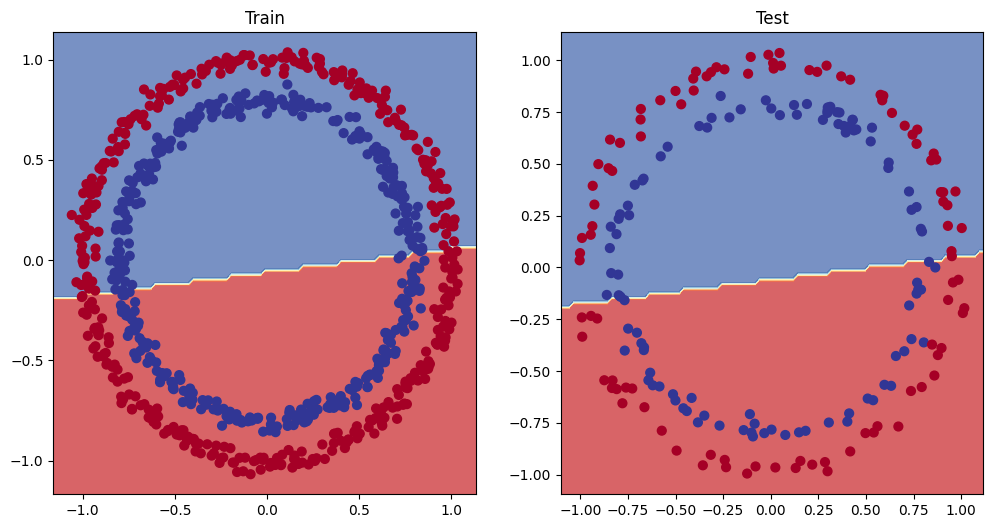

In [44]:
# plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train_tensor, y_train_tensor)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test_tensor, y_test_tensor)

**IMPROVING**

  1.  MORE LAYERS
  2. MORE HIDDEN UNITS(from 5 to 10)
  3. FIT FOR LONGER
  4. CHANGE ACTIVATION FUNCTION
  5. CHANGE LEARNING RATE
